IMPORT LIBRARIES

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

DATASET INTEGRATION AND PREPARATION

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100.0%
100.0%
100.0%
100.0%


CNN MODEL DEFINITION

In [3]:
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25)
        )
        self.fc1 = nn.Linear(32 * 7 * 7, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

TRAINING SETUP & LOSS AND OPTIMIZER

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


MODEL TRAINING

In [5]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch}] Step [{batch_idx+1}/{len(train_loader)}] - Loss: {loss.item():.4f}")

MODEL EVALUATION

In [6]:
def evaluate():
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / len(test_dataset)
    print(f"Test Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy

for epoch in range(1, 11):
    train_one_epoch(epoch)
    evaluate()

Epoch [1] Step [100/469] - Loss: 0.2392
Epoch [1] Step [200/469] - Loss: 0.1168
Epoch [1] Step [300/469] - Loss: 0.2214
Epoch [1] Step [400/469] - Loss: 0.1017
Test Loss: 0.0701 | Accuracy: 97.86%
Epoch [2] Step [100/469] - Loss: 0.0595
Epoch [2] Step [200/469] - Loss: 0.0814
Epoch [2] Step [300/469] - Loss: 0.0376
Epoch [2] Step [400/469] - Loss: 0.1076
Test Loss: 0.0521 | Accuracy: 98.26%
Epoch [3] Step [100/469] - Loss: 0.0615
Epoch [3] Step [200/469] - Loss: 0.0374
Epoch [3] Step [300/469] - Loss: 0.0194
Epoch [3] Step [400/469] - Loss: 0.0269
Test Loss: 0.0344 | Accuracy: 98.85%
Epoch [4] Step [100/469] - Loss: 0.0227
Epoch [4] Step [200/469] - Loss: 0.0379
Epoch [4] Step [300/469] - Loss: 0.1149
Epoch [4] Step [400/469] - Loss: 0.0646
Test Loss: 0.0337 | Accuracy: 98.81%
Epoch [5] Step [100/469] - Loss: 0.0223
Epoch [5] Step [200/469] - Loss: 0.0118
Epoch [5] Step [300/469] - Loss: 0.0602
Epoch [5] Step [400/469] - Loss: 0.0181
Test Loss: 0.0369 | Accuracy: 98.81%
Epoch [6] Step 

SAVE THE MODEL

In [7]:
torch.save(model.state_dict(), "mnist_digit_cnn.pth")
print("\nModel saved successfully ✅")


Model saved successfully ✅


VISUALISE SAMPLE PREDICTIONS

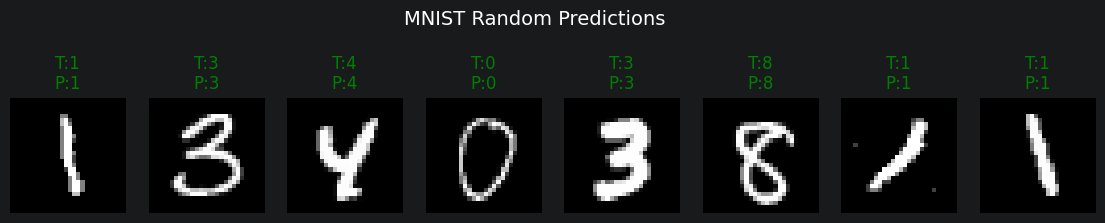

In [8]:
def show_random_predictions(model, dataset, n_samples=8):
    model.eval()
    plt.figure(figsize=(14, 3))
    chosen = random.sample(range(len(dataset)), n_samples)

    for i, idx in enumerate(chosen):
        image, label = dataset[idx]
        img_input = image.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_input).argmax(dim=1).item()

        plt.subplot(1, n_samples, i+1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"T:{label}\nP:{pred}", color='green' if label == pred else 'red')
        plt.axis('off')

    plt.suptitle("MNIST Random Predictions", fontsize=14)
    plt.show()

show_random_predictions(model, test_dataset)